[INFO] Filtered metadata rows: 7,381,762
[INFO] Topic assignments in model: 7,381,762
[INFO] Grouped label rows: 84


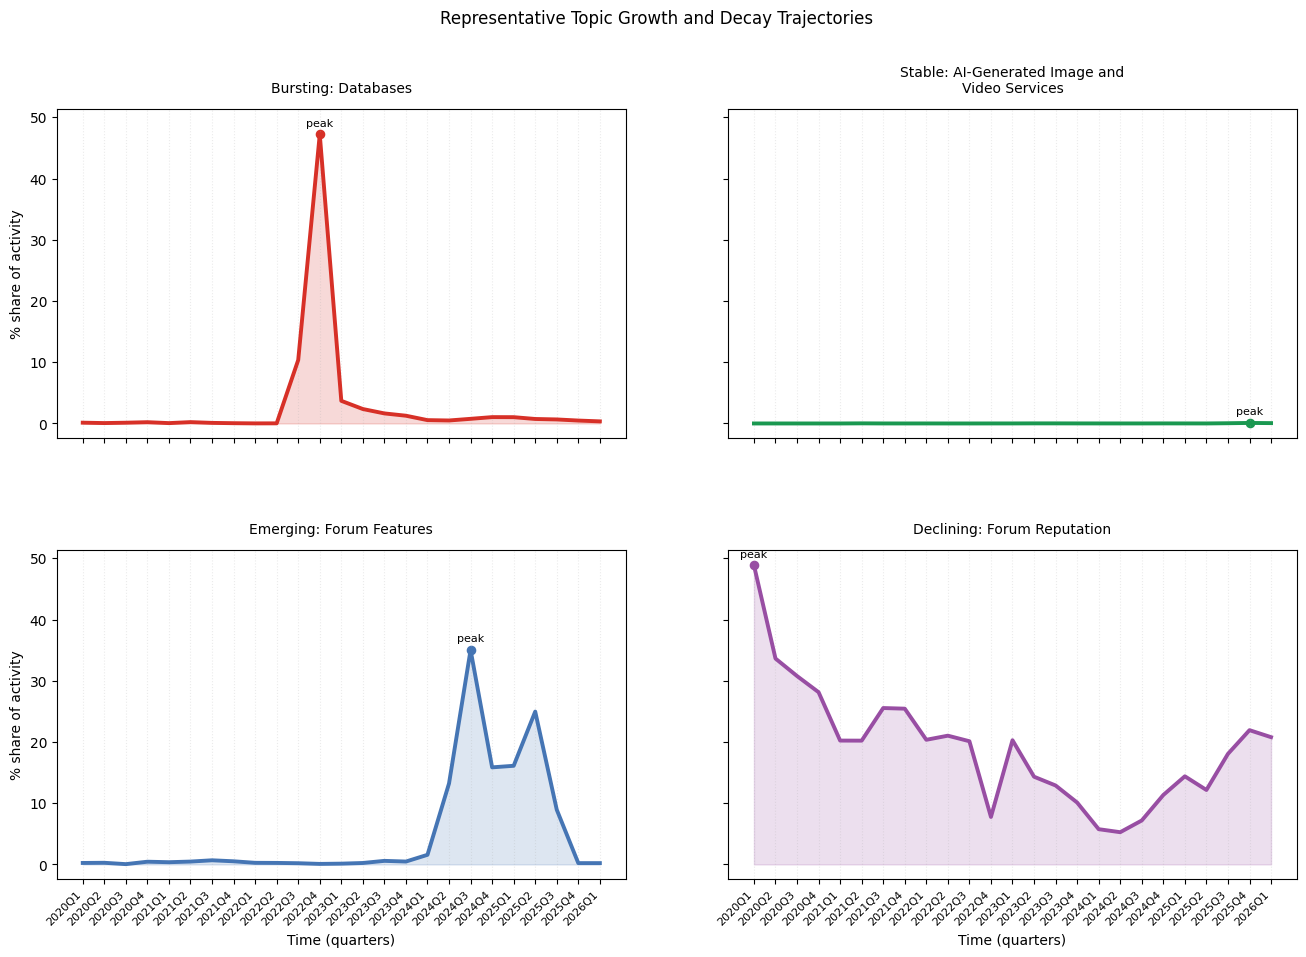

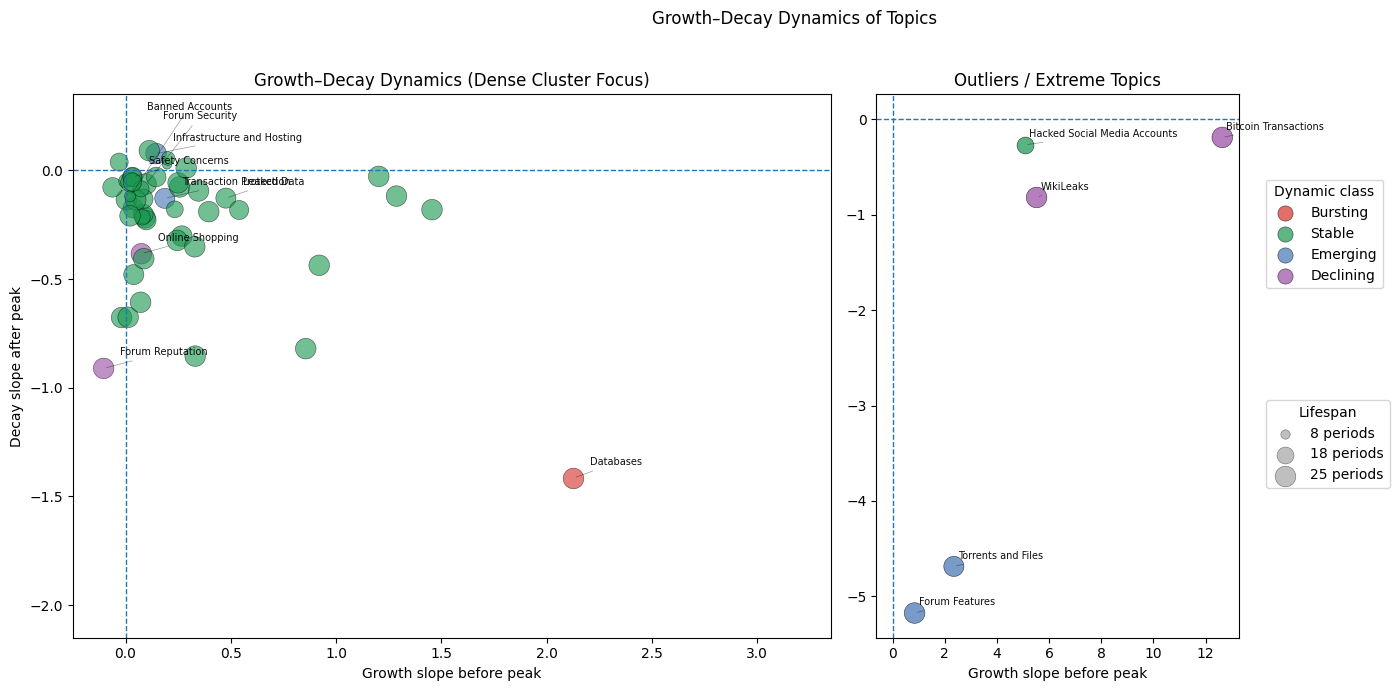

Saved representative small-multiples PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2b/growth_decay_representative_small_multiples_v6.pdf
Saved representative small-multiples PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2b/growth_decay_representative_small_multiples_v6.png
Saved focus/outlier scatter PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2b/growth_decay_scatter_focus_outliers_v6.pdf
Saved focus/outlier scatter PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2b/growth_decay_scatter_focus_outliers_v6.png
Saved topic feature table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2b/growth_decay_topic_features_v6.csv
Saved representative topic table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2b/growth_decay_representative_topics_v6.csv
Saved class count table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2b/growth_decay_class_counts_v6.csv

Representative topics:


,Final,Dynamic_Class,Peak_Period,Peak_Value,Lifespan_Periods,Peak_Share_of_Total,Growth_Slope,Decay_Slope,Total_Count
0,Databases,Bursting,2022Q4,47.201700,25,0.641759,2.128166,-1.463085,192833
1,AI-Generated Image and Video Services,Stable,2025Q4,0.085551,20,0.299257,0.001714,-0.028830,1493
2,Forum Features,Emerging,2024Q3,35.023119,25,0.288838,0.746074,-5.103940,524089
3,Forum Reputation,Declining,2020Q1,48.862916,25,0.102546,0.000000,-0.888803,903883



Dynamic class counts:


,Dynamic_Class,Count
0,Stable,46
1,Emerging,4
2,Declining,4
3,Bursting,1



Top topic features:


,Final,Peak_Period,Peak_Index,Peak_Value,First_Index,Last_Index,Lifespan_Periods,Active_Periods,Active_Period_Ratio,Growth_Slope,Decay_Slope,Full_Slope,Variance,Peak_to_Mean,Peak_Width,Peak_Share_of_Total,Dynamic_Class,Total_Count
0,Torrents and Files,2024Q1,16,52.175093,1,24,24,24,0.96,2.315192,-4.633842,0.518766,181.802476,5.844620,1,0.233785,Emerging,1026851
1,Forum Reputation,2020Q1,0,48.862916,0,24,25,25,1.00,0.000000,-0.888803,-0.888803,93.273472,2.563661,1,0.102546,Declining,903883
2,Online Shopping,2020Q1,0,33.659509,0,24,25,25,1.00,0.000000,-0.502929,-0.502929,44.376437,2.805807,1,0.112232,Declining,558270
3,Forum Features,2024Q3,18,35.023119,0,24,25,25,1.00,0.746074,-5.103940,0.629939,81.281787,7.220948,1,0.288838,Emerging,524089
4,Infrastructure and Hosting,2026Q1,24,30.157047,0,24,25,25,1.00,0.339903,0.000000,0.339903,51.511619,6.336732,1,0.253469,Emerging,461151
5,Transaction Protection,2022Q4,11,7.143057,1,24,24,24,0.96,0.316649,0.006081,0.258450,6.226704,2.802651,3,0.112106,Emerging,243077
6,Forum Security,2023Q3,14,5.333833,0,24,25,25,1.00,0.084949,-0.035895,0.117787,2.199798,2.076844,5,0.083074,Stable,204509
7,Counterfeit Money,2023Q1,12,6.748477,0,24,25,25,1.00,0.298839,-0.315269,0.070897,2.827201,2.249708,2,0.089988,Stable,197892
8,Databases,2022Q4,11,47.201700,0,24,25,25,1.00,2.128166,-1.463085,-0.015061,85.887550,16.043965,1,0.641759,Bursting,192833
9,Online Banking,2022Q1,8,12.689310,0,24,25,25,1.00,1.004930,-0.493453,0.012246,10.237754,4.005347,2,0.160214,Stable,175989


In [15]:
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from bertopic import BERTopic
from pathlib import Path
import textwrap

# -------------------------
# Fix for BERTopic loading
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X


# -------------------------
# PATHS
# -------------------------
JSONL_PATH = Path("preprocessed_from_disk.jsonl")
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/final_labeling.csv")

OUT_DIR = Path("./rq2b")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_TRAJ_PDF = OUT_DIR / "growth_decay_representative_small_multiples_v6.pdf"
FIG_TRAJ_PNG = OUT_DIR / "growth_decay_representative_small_multiples_v6.png"
FIG_SCATTER_PDF = OUT_DIR / "growth_decay_scatter_focus_outliers_v6.pdf"
FIG_SCATTER_PNG = OUT_DIR / "growth_decay_scatter_focus_outliers_v6.png"

OUT_TOPIC_FEATURES = OUT_DIR / "growth_decay_topic_features_v6.csv"
OUT_REPRESENTATIVES = OUT_DIR / "growth_decay_representative_topics_v6.csv"
OUT_CLASS_COUNTS = OUT_DIR / "growth_decay_class_counts_v6.csv"

# -------------------------
# SETTINGS
# -------------------------
PERIOD_MODE = "Q"
DOC_FIELD_PRIMARY = "preprocessed_trafilatura"
DOC_FIELD_FALLBACK = "preprocessed_content"
MAX_LABEL_LEN = 70
TITLE_WRAP = 32
REP_CLASSES = ["Bursting", "Stable", "Emerging", "Declining"]

# Focus view thresholds
FOCUS_MAX_GROWTH = 3.0
FOCUS_MIN_DECAY = -2.0

# Bubble sizes
BUBBLE_MIN = 45
BUBBLE_MAX = 220

# Jitter settings
JITTER_X = 0.10
JITTER_Y = 0.08

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# -------------------------
# HELPERS
# -------------------------
def detect_delimiter(path: Path):
    with open(path, "r", encoding="utf-8-sig") as f:
        line = f.readline()
    return ";" if line.count(";") > line.count(",") else ","


def load_grouped_labels(path: Path):
    rows = []
    delim = detect_delimiter(path)

    with open(path, "r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=delim)

        for r in reader:
            tids = (r.get("Topic_ID") or "").split(",")
            final_label = (r.get("Final") or "").strip()

            for t in tids:
                t = t.strip()
                if t.isdigit():
                    rows.append({
                        "Topic": int(t),
                        "Final": final_label
                    })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No rows parsed from final_labeling.csv")
    return df


def load_filtered_metadata_from_jsonl(path: Path, primary_field: str, fallback_field: str):
    rows = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            text = rec.get(primary_field, "")
            if isinstance(text, str) and text.strip():
                pass
            else:
                text = rec.get(fallback_field, "")
                if not (isinstance(text, str) and text.strip()):
                    continue

            rows.append({"created_at": rec.get("created_at")})

    return pd.DataFrame(rows)


def build_period_column(dt_series, mode="Q"):
    if mode == "M":
        return dt_series.dt.to_period("M").astype(str)
    elif mode == "Q":
        return dt_series.dt.to_period("Q").astype(str)
    elif mode == "4M":
        years = dt_series.dt.year
        months = dt_series.dt.month
        bin_start = (((months - 1) // 4) * 4) + 1
        return years.astype(str) + "-" + bin_start.astype(str).str.zfill(2)
    else:
        raise ValueError("PERIOD_MODE must be one of: 'M', 'Q', '4M'")


def shorten(label, max_len=70):
    label = str(label)
    return label if len(label) <= max_len else label[:max_len - 3] + "..."


def wrap_title(text, width=32):
    return "\n".join(textwrap.wrap(str(text), width=width))


def add_repel_labels(ax, df, x_col, y_col, text_col, fontsize=8, max_iter=60,
                     dx=0.03, dy=0.03, x_bounds=None, y_bounds=None):
    """
    Simple deterministic repel for label positions.
    """
    placed = []

    for _, row in df.iterrows():
        x = float(row[x_col])
        y = float(row[y_col])
        label = str(row[text_col])

        lx = x + dx
        ly = y + dy

        for _ in range(max_iter):
            overlap = False
            for px, py in placed:
                if abs(lx - px) < dx * 1.8 and abs(ly - py) < dy * 1.6:
                    ly += dy
                    overlap = True
            if not overlap:
                break

        if x_bounds is not None:
            lx = min(max(lx, x_bounds[0]), x_bounds[1])
        if y_bounds is not None:
            ly = min(max(ly, y_bounds[0]), y_bounds[1])

        ax.annotate(
            label,
            (x, y),
            xytext=(lx, ly),
            textcoords="data",
            fontsize=fontsize,
            alpha=0.95,
            arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.4)
        )
        placed.append((lx, ly))


xlabel = {
    "M": "Time (months)",
    "Q": "Time (quarters)",
    "4M": "Time (4-month periods)"
}[PERIOD_MODE]

CLASS_COLORS = {
    "Bursting": "#d73027",
    "Stable": "#1a9850",
    "Emerging": "#4575b4",
    "Declining": "#984ea3"
}

# -------------------------
# LOAD DATA
# -------------------------
topic_model = BERTopic.load(MODEL_PATH)
topics = topic_model.topics_

meta_df = load_filtered_metadata_from_jsonl(
    JSONL_PATH,
    primary_field=DOC_FIELD_PRIMARY,
    fallback_field=DOC_FIELD_FALLBACK
)

labels_df = load_grouped_labels(LABELS_PATH)

print(f"[INFO] Filtered metadata rows: {len(meta_df):,}")
print(f"[INFO] Topic assignments in model: {len(topics):,}")
print(f"[INFO] Grouped label rows: {len(labels_df):,}")

if len(meta_df) != len(topics):
    raise ValueError(
        f"Mismatch after training-style filtering: "
        f"{len(meta_df):,} filtered rows vs {len(topics):,} topic assignments."
    )

meta_df = meta_df.copy()
meta_df["Topic"] = topics
meta_df = meta_df[(meta_df["Topic"] != -1) & meta_df["created_at"].notna()].copy()

meta_df["datetime"] = pd.to_datetime(meta_df["created_at"], unit="ms", errors="coerce")
meta_df = meta_df[meta_df["datetime"].notna()].copy()
meta_df["Period"] = build_period_column(meta_df["datetime"], PERIOD_MODE)

df = meta_df.merge(labels_df, on="Topic", how="left")
df["Final"] = df["Final"].fillna("Unlabeled")

# -------------------------
# AGGREGATE TO FINAL TOPIC x PERIOD
# -------------------------
long_df = (
    df.groupby(["Period", "Final"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

long_df["Percent"] = (
    long_df.groupby("Period")["Count"]
    .transform(lambda s: 100 * s / s.sum())
)

wide = long_df.pivot(index="Final", columns="Period", values="Percent").fillna(0)
topic_strength = (
    long_df.groupby("Final", as_index=False)["Count"]
    .sum()
    .rename(columns={"Count": "Total_Count"})
)

# -------------------------
# FEATURE EXTRACTION
# -------------------------
feature_rows = []
periods = list(wide.columns)

for topic in wide.index:
    y = wide.loc[topic].values.astype(float)
    x = np.arange(len(y))

    peak_idx = int(np.argmax(y))
    peak_val = float(y[peak_idx])

    active_idx = np.where(y > 0)[0]
    active_periods = int(len(active_idx))

    if len(active_idx) > 0:
        first_idx = int(active_idx[0])
        last_idx = int(active_idx[-1])
        lifespan_periods = last_idx - first_idx + 1
    else:
        first_idx = 0
        last_idx = 0
        lifespan_periods = 0

    if peak_idx > first_idx:
        x_growth = np.arange(first_idx, peak_idx + 1)
        y_growth = y[first_idx:peak_idx + 1]
        growth_slope = linregress(x_growth, y_growth).slope if len(np.unique(y_growth)) > 1 else 0.0
    else:
        growth_slope = 0.0

    if last_idx > peak_idx:
        x_decay = np.arange(peak_idx, last_idx + 1)
        y_decay = y[peak_idx:last_idx + 1]
        decay_slope = linregress(x_decay, y_decay).slope if len(np.unique(y_decay)) > 1 else 0.0
    else:
        decay_slope = 0.0

    full_slope = linregress(x, y).slope if len(np.unique(y)) > 1 else 0.0
    mean_val = float(np.mean(y))
    variance = float(np.var(y))
    peak_to_mean = peak_val / mean_val if mean_val > 0 else 0.0
    peak_width = int(np.sum(y >= 0.8 * peak_val)) if peak_val > 0 else 0

    total_sum = float(np.sum(y))
    peak_share_of_total = peak_val / total_sum if total_sum > 0 else 0.0
    active_period_ratio = active_periods / len(y) if len(y) > 0 else 0.0

    if (
        peak_share_of_total >= 0.35
        and peak_width <= 2
        and decay_slope < -0.3
    ):
        dynamic_class = "Bursting"
    elif full_slope > 0.15:
        dynamic_class = "Emerging"
    elif full_slope < -0.15:
        dynamic_class = "Declining"
    else:
        dynamic_class = "Stable"

    feature_rows.append({
        "Final": topic,
        "Peak_Period": periods[peak_idx],
        "Peak_Index": peak_idx,
        "Peak_Value": peak_val,
        "First_Index": first_idx,
        "Last_Index": last_idx,
        "Lifespan_Periods": lifespan_periods,
        "Active_Periods": active_periods,
        "Active_Period_Ratio": active_period_ratio,
        "Growth_Slope": growth_slope,
        "Decay_Slope": decay_slope,
        "Full_Slope": full_slope,
        "Variance": variance,
        "Peak_to_Mean": peak_to_mean,
        "Peak_Width": peak_width,
        "Peak_Share_of_Total": peak_share_of_total,
        "Dynamic_Class": dynamic_class
    })

features_df = pd.DataFrame(feature_rows).merge(topic_strength, on="Final", how="left")
features_df = features_df.sort_values(["Total_Count", "Peak_Value"], ascending=[False, False]).reset_index(drop=True)
features_df.to_csv(OUT_TOPIC_FEATURES, sep=";", index=False, encoding="utf-8-sig")

class_counts = (
    features_df["Dynamic_Class"]
    .value_counts()
    .rename_axis("Dynamic_Class")
    .reset_index(name="Count")
)
class_counts.to_csv(OUT_CLASS_COUNTS, sep=";", index=False, encoding="utf-8-sig")

# -------------------------
# PICK REPRESENTATIVE TOPICS
# -------------------------
representatives = []

for cls in REP_CLASSES:
    subset = features_df[features_df["Dynamic_Class"] == cls].copy()

    if subset.empty:
        continue

    if cls == "Bursting":
        subset = subset.sort_values(
            ["Peak_Share_of_Total", "Decay_Slope", "Peak_Width", "Total_Count"],
            ascending=[False, True, True, False]
        )
    elif cls == "Stable":
        subset = subset.sort_values(
            ["Variance", "Total_Count", "Lifespan_Periods"],
            ascending=[True, False, False]
        )
    elif cls == "Emerging":
        subset = subset.sort_values(
            ["Full_Slope", "Total_Count"],
            ascending=[False, False]
        )
    elif cls == "Declining":
        subset = subset.sort_values(
            ["Full_Slope", "Total_Count"],
            ascending=[True, False]
        )

    representatives.append(subset.head(1))

rep_df = pd.concat(representatives, ignore_index=True) if representatives else pd.DataFrame(columns=features_df.columns)

if "Bursting" not in rep_df["Dynamic_Class"].values:
    used = set(rep_df["Final"]) if not rep_df.empty else set()
    burst_fallback = (
        features_df[~features_df["Final"].isin(used)]
        .sort_values(
            ["Peak_Share_of_Total", "Decay_Slope", "Peak_Width", "Total_Count"],
            ascending=[False, True, True, False]
        )
        .head(1)
        .copy()
    )
    if not burst_fallback.empty:
        burst_fallback["Dynamic_Class"] = "Bursting"
        rep_df = pd.concat([rep_df, burst_fallback], ignore_index=True)

rep_df.to_csv(OUT_REPRESENTATIVES, sep=";", index=False, encoding="utf-8-sig")

# -------------------------
# CHART 1: SMALL MULTIPLES
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, cls in zip(axes, REP_CLASSES):
    row = rep_df[rep_df["Dynamic_Class"] == cls]

    if row.empty:
        ax.set_title(cls, fontsize=11, pad=10)
        ax.text(0.5, 0.5, "No representative topic", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue

    topic = row["Final"].iloc[0]
    y = wide.loc[topic]
    color = CLASS_COLORS.get(cls, "#333333")

    ax.plot(y.index, y.values, linewidth=2.8, color=color)
    ax.fill_between(range(len(y.values)), y.values, alpha=0.18, color=color)

    peak_idx = int(np.argmax(y.values))
    ax.scatter(peak_idx, y.values[peak_idx], s=35, color=color)
    ax.annotate(
        "peak",
        (peak_idx, y.values[peak_idx]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

    title_text = f"{cls}: {shorten(topic, MAX_LABEL_LEN)}"
    ax.set_title(wrap_title(title_text, TITLE_WRAP), fontsize=10, pad=12)
    ax.grid(axis="x", linestyle=":", alpha=0.25)

    ax.set_xticks(range(len(y.index)))
    ax.set_xticklabels(y.index, rotation=45, ha="right", fontsize=8)

for ax in axes[2:]:
    ax.set_xlabel(xlabel)
for ax in [axes[0], axes[2]]:
    ax.set_ylabel("% share of activity")

fig.suptitle("Representative Topic Growth and Decay Trajectories", y=0.98, fontsize=12)
fig.subplots_adjust(top=0.88, hspace=0.34, wspace=0.18)
plt.savefig(FIG_TRAJ_PDF, bbox_inches="tight")
plt.savefig(FIG_TRAJ_PNG, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# CHART 2: TWO-PANEL SCATTER
# -------------------------
plot_df = features_df.copy()

# bubble size = lifespan
plot_df["bubble_size"] = np.interp(
    plot_df["Lifespan_Periods"],
    (plot_df["Lifespan_Periods"].min(), plot_df["Lifespan_Periods"].max()),
    (BUBBLE_MIN, BUBBLE_MAX)
)

# deterministic jitter
rng = np.random.default_rng(42)
plot_df["Growth_Slope_j"] = plot_df["Growth_Slope"] + rng.normal(0, JITTER_X, size=len(plot_df))
plot_df["Decay_Slope_j"] = plot_df["Decay_Slope"] + rng.normal(0, JITTER_Y, size=len(plot_df))

focus_mask = (
    (plot_df["Growth_Slope"] <= FOCUS_MAX_GROWTH) &
    (plot_df["Decay_Slope"] >= FOCUS_MIN_DECAY)
)

focus_df = plot_df[focus_mask].copy()
outlier_df = plot_df[~focus_mask].copy()

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 7),
    gridspec_kw={"width_ratios": [2.3, 1.1]}
)

# ---- Left: dense cluster focus
for cls, sub in focus_df.groupby("Dynamic_Class"):
    ax1.scatter(
        sub["Growth_Slope_j"],
        sub["Decay_Slope_j"],
        s=sub["bubble_size"],
        alpha=0.62,
        color=CLASS_COLORS.get(cls, None),
        edgecolors="black",
        linewidths=0.4,
        label=cls
    )

ax1.axhline(0, linestyle="--", linewidth=1)
ax1.axvline(0, linestyle="--", linewidth=1)
ax1.set_xlim(-0.25, FOCUS_MAX_GROWTH + 0.35)
ax1.set_ylim(FOCUS_MIN_DECAY - 0.15, 0.35)
ax1.set_xlabel("Growth slope before peak")
ax1.set_ylabel("Decay slope after peak")
ax1.set_title("Growth–Decay Dynamics (Dense Cluster Focus)")

# label fewer but with full names
focus_annot = pd.concat([
    focus_df.sort_values("Total_Count", ascending=False).head(5),
    focus_df.sort_values("Peak_Share_of_Total", ascending=False).head(5),
    focus_df.sort_values("Lifespan_Periods", ascending=False).head(4)
]).drop_duplicates("Final").head(9).copy()

add_repel_labels(
    ax1,
    focus_annot,
    x_col="Growth_Slope_j",
    y_col="Decay_Slope_j",
    text_col="Final",
    fontsize=7,
    dx=0.08,
    dy=0.06,
    x_bounds=(-0.2, FOCUS_MAX_GROWTH + 0.25),
    y_bounds=(FOCUS_MIN_DECAY + 0.05, 0.28)
)

# ---- Right: outliers
for cls, sub in outlier_df.groupby("Dynamic_Class"):
    ax2.scatter(
        sub["Growth_Slope_j"],
        sub["Decay_Slope_j"],
        s=sub["bubble_size"],
        alpha=0.72,
        color=CLASS_COLORS.get(cls, None),
        edgecolors="black",
        linewidths=0.4
    )

ax2.axhline(0, linestyle="--", linewidth=1)
ax2.axvline(0, linestyle="--", linewidth=1)
ax2.set_xlabel("Growth slope before peak")
ax2.set_ylabel("")
ax2.set_title("Outliers / Extreme Topics")

# full names for outliers too
outlier_annot = outlier_df.sort_values("Total_Count", ascending=False).head(8).copy()
add_repel_labels(
    ax2,
    outlier_annot,
    x_col="Growth_Slope_j",
    y_col="Decay_Slope_j",
    text_col="Final",
    fontsize=7,
    dx=0.15,
    dy=0.08
)

# legends more to the left than before
handles_class = []
labels_class = []
for cls in REP_CLASSES:
    handles_class.append(
        ax2.scatter([], [], s=120, color=CLASS_COLORS[cls], alpha=0.7, edgecolors="black", linewidths=0.4)
    )
    labels_class.append(cls)

fig.legend(
    handles_class, labels_class, title="Dynamic class",
    loc="center left", bbox_to_anchor=(0.79, 0.66)
)

size_vals = sorted(plot_df["Lifespan_Periods"].dropna().unique())
if len(size_vals) >= 3:
    sample_sizes = [size_vals[0], size_vals[len(size_vals)//2], size_vals[-1]]
else:
    sample_sizes = sorted(set(size_vals))

handles_size = []
labels_size = []
for val in sample_sizes:
    s = np.interp(
        val,
        (plot_df["Lifespan_Periods"].min(), plot_df["Lifespan_Periods"].max()),
        (BUBBLE_MIN, BUBBLE_MAX)
    )
    handles_size.append(
        ax2.scatter([], [], s=s, color="gray", alpha=0.5, edgecolors="black", linewidths=0.4)
    )
    labels_size.append(f"{int(val)} periods")

fig.legend(
    handles_size, labels_size, title="Lifespan",
    loc="center left", bbox_to_anchor=(0.79, 0.36)
)

fig.suptitle("Growth–Decay Dynamics of Topics", y=0.98, fontsize=12)
fig.tight_layout(rect=[0, 0, 0.84, 0.96])
plt.savefig(FIG_SCATTER_PDF, bbox_inches="tight")
plt.savefig(FIG_SCATTER_PNG, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# OUTPUT SUMMARY
# -------------------------
print(f"Saved representative small-multiples PDF to: {FIG_TRAJ_PDF.resolve()}")
print(f"Saved representative small-multiples PNG to: {FIG_TRAJ_PNG.resolve()}")
print(f"Saved focus/outlier scatter PDF to: {FIG_SCATTER_PDF.resolve()}")
print(f"Saved focus/outlier scatter PNG to: {FIG_SCATTER_PNG.resolve()}")
print(f"Saved topic feature table to: {OUT_TOPIC_FEATURES.resolve()}")
print(f"Saved representative topic table to: {OUT_REPRESENTATIVES.resolve()}")
print(f"Saved class count table to: {OUT_CLASS_COUNTS.resolve()}")

print("\nRepresentative topics:")
display(rep_df[[
    "Final", "Dynamic_Class", "Peak_Period", "Peak_Value",
    "Lifespan_Periods", "Peak_Share_of_Total",
    "Growth_Slope", "Decay_Slope", "Total_Count"
]])

print("\nDynamic class counts:")
display(class_counts)

print("\nTop topic features:")
display(features_df.head(20))